In [1]:
import jax
import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro import plate
from numpyro.distributions import constraints

/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
from itertools import product, accumulate
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  
from functools import reduce
from tqdm import trange
from typing import List, Dict, Any, Tuple
import copy
import time

In [3]:
def select_most_diverse(samples: jnp.ndarray, num_select: int = 3):
    """
    samples: (N, D)
    returns: python list of selected indices
    """
    N = samples.shape[0]
    selected = [0]

    # pairwise Euclidean distances
    diff = samples[:, None, :] - samples[None, :, :]   # (N, N, D)
    dist_matrix = jnp.linalg.norm(diff, axis=-1)      # (N, N)

    for _ in range(num_select - 1):
        dist_to_selected = dist_matrix[jnp.array(selected), :]  # (len(selected), N)
        min_dist = dist_to_selected.min(axis=0)                # (N,)

        # Set already selected indices to -1 so they won't be picked
        min_dist = min_dist.at[jnp.array(selected)].set(-1.0)
        next_idx = int(jnp.argmax(min_dist))
        selected.append(next_idx)

    return selected

def generate_distinct_distributions(key, N, V, concent=0.8):
    """
    Draw N samples from Dirichlet(alpha).
    - If concent is scalar → alpha = concent * ones(V)
    - If concent is vector of shape (V,) → use directly
    Returns: (N, V)
    """
    if jnp.ndim(concent) == 0:  # scalar
        alpha = jnp.ones((V,), dtype=jnp.float32) * float(concent)
    else:  # vector
        alpha = jnp.array(concent, dtype=jnp.float32)
        assert alpha.shape[0] == V, f"alpha length {alpha.shape[0]} != V={V}"

    alpha = jnp.clip(alpha, a_min=1e-6)
    keys = random.split(key, N)
    samples = jnp.stack([random.dirichlet(k, alpha) for k in keys], axis=0)
    return samples

def generate_distinct_components(key, K, V, peak_strength=5.0, base_concent=0.1):
    """
    Create K component-word distributions (K, V) with a 'peak' at index k * V // K
    """
    comps = []
    keys = random.split(key, K)
    for k in range(K):
        alpha = jnp.ones((V,), dtype=jnp.float32) * base_concent
        alpha = alpha.at[(k * V) // K].set(peak_strength)
        comps.append(random.dirichlet(keys[k], alpha))
    return jnp.stack(comps, axis=0)  # (K, V)

def generate_hierarchical_mixture_data_jax(
    struct_upbd,
    N_per_base: int = 20,
    M: int = 200,
    V: int = 100,
    seed: int = 42,
):
    """
    Returns a dict similar to your PyTorch version, using JAX arrays.
    """
    key = random.PRNGKey(seed)
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base

    # y means and stds
    y_means = jnp.linspace(-num_features / 4, num_features / 4, num=num_features)
    key, sub = random.split(key)
    y_stds = 0.1 + 0.1 * random.uniform(sub, shape=(num_features,))

    alpha_1 = 0.8
    assert num_features >= num_base_per_super * num_super
    super_window = int(num_features / num_super)

    # generate super_core: shape (num_super, super_window)
    key, sub = random.split(key)
    super_core = generate_distinct_distributions(sub, num_super, super_window, concent=alpha_1)

    # build super_prototypes (num_super, num_features)
    blocks = int(num_features / super_window)
    super_prototypes = jnp.zeros((num_super, num_features))
    for i in range(blocks):
        mask = (jnp.arange(num_super) % blocks) == i  # (num_super,)
        mask = mask.astype(jnp.float32)[:, None]      # (num_super, 1)
        block_vals = super_core * mask
        super_prototypes = super_prototypes.at[:, i * super_window:(i + 1) * super_window].set(block_vals)

    # normalize
    super_prototypes = super_prototypes / super_prototypes.sum(axis=-1, keepdims=True)

    # alpha_2 cycling
    alpha_2 = [6, 8] * ((num_super + 1) // 2)
    alpha_2 = alpha_2[:num_super]

    # base prototypes
    base_prototypes_list = []
    for super_id in range(num_super):
        key, sub = random.split(key)
        candids = generate_distinct_distributions(
            sub, num_base_per_super * 5, num_features,
            concent=alpha_2[super_id] * super_prototypes[super_id]
        )
        sel = select_most_diverse(candids, num_select=num_base_per_super)
        chosen = candids[jnp.array(sel), :]
        base_prototypes_list.append(chosen)

    base_prototypes = jnp.stack(base_prototypes_list, axis=0)  # (num_super, num_base_per_super, num_features)

    # word components
    key, sub = random.split(key)
    word_dists = generate_distinct_components(sub, num_features, V, peak_strength=1.0, base_concent=0.1)

    # apply overlapping mask scheme
    word_block = int(V / (num_super * num_base_per_super))
    overlap = int(word_block / 2) if word_block >= 2 else 0
    masks = jnp.zeros_like(word_dists)
    for i in range(num_features):
        if i < int(num_features / 2):
            idxs = jnp.arange(i * overlap, i * overlap + word_block)
        else:
            idxs = jnp.arange(-(i * overlap + word_block) - 1, -i * overlap - 1)
        idxs = (idxs % V).astype(int)
        mask = jnp.zeros((V,), dtype=jnp.bool_)
        mask = mask.at[idxs].set(True)
        masks = masks.at[i].set(mask.astype(jnp.float32))

    word_dists = word_dists * masks
    row_sums = word_dists.sum(axis=-1, keepdims=True)
    word_dists = word_dists / (row_sums + 1e-12)

    # generate documents
    X_list, y_list, labels_base, labels_super, labels_x, labels_y = [], [], [], [], [], []

    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id * num_base_per_super + base_offset
            base_proto = base_prototypes[super_id, base_offset]

            for _ in range(samples_per_base):
                doc_words = []
                docs_labels = []
                for _w in range(M):
                    key, sub = random.split(key)
                    comp_logits = jnp.log(base_proto + 1e-12)
                    comp_id = int(random.categorical(sub, comp_logits))
                    docs_labels.append(comp_id)
                    key, sub = random.split(key)
                    word_logits = jnp.log(word_dists[comp_id] + 1e-12)
                    word_idx = int(random.categorical(sub, word_logits))
                    doc_words.append(jax.nn.one_hot(word_idx, V))
                doc = jnp.stack(doc_words, axis=0)
                doc_z = jnp.array(docs_labels)
                X_list.append(doc)
                labels_x.append(doc_z)

                key, sub = random.split(key)
                comp_for_y = int(random.categorical(sub, jnp.log(base_proto + 1e-12)))
                labels_y.append(comp_for_y)
                key, sub = random.split(key)
                y_val = y_means[comp_for_y] + y_stds[comp_for_y] * random.normal(sub, shape=())
                y_list.append(y_val)
                labels_base.append(base_id)
                labels_super.append(super_id)

    X_data = jnp.stack(X_list, axis=0)
    y_data = jnp.stack(y_list, axis=0)
    labels_base = jnp.array(labels_base)
    labels_super = jnp.array(labels_super)
    labels_x = jnp.array(labels_x)
    labels_y = jnp.array(labels_y)

    return {
        "x": X_data,
        "y": y_data,
        "super_labels": labels_super,
        "base_labels": labels_base,
        "x_labels": labels_x,
        "y_labels": labels_y,
        "word_dists": word_dists,
        "reg_means": y_means,
        "reg_std": y_stds,
        "super_mix_weights": super_prototypes,
        "child_mix_weights": base_prototypes,
    }

# Example usage
if __name__ == "__main__":
    struct_upbd = {"G0": 36, "G1": 3, "G2": 4}   # example
    data = generate_hierarchical_mixture_data_jax(struct_upbd, N_per_base=3, M=10, V=50, seed=0)
    print("x shape:", data["x"].shape)
    print("y shape:", data["y"].shape)
    print("word_dists shape:", data["word_dists"].shape)
    print("super mix shape:", data["super_mix_weights"].shape)
    print("child mix shape:", data["child_mix_weights"].shape)


x shape: (36, 10, 50)
y shape: (36,)
word_dists shape: (36, 50)
super mix shape: (3, 36)
child mix shape: (3, 4, 36)


In [4]:
def tsne_visualization(data, struct_upbd):
    x_agg = data["x"].sum(axis=1)
    # Run t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    x_embedded = tsne.fit_transform(x_agg)

    # Plot t-SNE colored by super categories
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
    plt.colorbar(scatter, ticks=range(6))
    plt.title("t-SNE of aggregated x colored by super categories")
    plt.xlabel("TSNE 1")
    plt.ylabel("TSNE 2")

    # Plot t-SNE colored by base categories
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
    plt.colorbar(scatter, ticks=range(18))
    plt.title("t-SNE of aggregated x colored by base categories")
    plt.xlabel("TSNE 1")
    plt.ylabel("TSNE 2")

    plt.show()

    # Plot distribution of y by super categories
    plt.figure(figsize=(8, 4))
    for super_id in range(struct_upbd["G1"]*struct_upbd["G2"]):
        y_vals = data["y"][data["super_labels"] == super_id]
        plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

    plt.title("Distribution of y by Super Categories")
    plt.xlabel("y")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

In [5]:
def umap_visualization(data, struct_upbd):
    x_agg = data["x"].sum(axis=1)
    # === UMAP projection ===
    reducer = umap.UMAP(random_state=0)
    x_umap = reducer.fit_transform(x_agg)


    # === UMAP Plots ===
    plt.figure(figsize=(10, 4))

    # Super category coloring
    plt.subplot(1, 2, 1)
    plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
    plt.title("UMAP by Super Category")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    # Base category coloring
    plt.subplot(1, 2, 2)
    plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
    plt.title("UMAP by Base Category")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    plt.show()

    # === Mixture Component Word Distributions ===
    num_components = struct_upbd["G0"]
    V = data["x"].shape[-1]
    word_dists = data["word_dists"]
    super_mix_weights = data["super_mix_weights"]
    child_mix_weights = data["child_mix_weights"]

    # Bar plots for each component
    fig, axs = plt.subplots(struct_upbd["G0"], 1, figsize=(20, 20))
    for i in range(num_components):
        ax = axs[i]
        ax.bar(range(V), word_dists[i])
        ax.set_title(f"Component {i}")
        ax.set_xlabel("Word ID")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, word_dists.max().item() * 1.1)

    fig.suptitle("Word Distributions of 10 Shared Mixture Components", fontsize=16)
    plt.show()

    # Bar plots for each component
    fig, axs = plt.subplots(struct_upbd["G1"], 1, figsize=(20, 6))
    for i in range(struct_upbd["G1"]):
        ax = axs[i]
        ax.bar(range(10), super_mix_weights[i])
        ax.set_title(f"Super Category {i}")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

    fig.suptitle("Super Category Weights of 10 Shared Mixture Components", fontsize=16)
    plt.show()

    # Bar plots for each component
    fig, axs = plt.subplots(struct_upbd["G1"]*struct_upbd["G2"], 1, figsize=(20, 20))
    for i in range(struct_upbd["G1"]):
        for j in range(struct_upbd["G2"]):
            ax = axs[i * struct_upbd["G2"] + j]
            ax.bar(range(10), child_mix_weights[i][j])
            ax.set_title(f"Super Category {i} Child Category {j}")
            ax.set_ylabel("Weights")
            ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

    fig.suptitle("Child Category Weights of 10 Shared Mixture Components", fontsize=16)
    plt.show()

In [6]:
def transfer_hierarchy_to_data_labels(local_cats: jnp.ndarray, level_dims: list[int]) -> jnp.ndarray:
    """
    Reverse of transfer_data_labels_to_hierarchy.
    Given local_cats and cluster sizes per level, reconstruct absolute labels.

    Args:
        local_cats: (N, L) array of local indices
        level_dims: list of ints, max cluster size per level

    Returns:
        data_labels: (N, L) array of absolute indices per level
    """
    N, L = local_cats.shape
    data_labels = jnp.zeros((N, L), dtype=jnp.int32)

    # level 0: absolute = local (super labels)
    data_labels = data_labels.at[:, 0].set(local_cats[:, 0])

    # deeper levels: absolute id = parent_abs * K[level] + local_id
    for level in range(1, L):
        parent_abs = data_labels[:, level - 1]
        data_labels = data_labels.at[:, level].set(parent_abs * level_dims[level] + local_cats[:, level])
    
    labels_per_level = [data_labels[:, i] for i in range(L)]

    return labels_per_level


In [7]:
def transfer_state_to_data(state, struct_upbd):
    """
    Given the HDMM state, extract the mixture components and category assignments
    in a format similar to the ground truth data for evaluation.

    Args:
        state: dict, the HDMM state returned by the model function or Gibbs sampler.
        struct_upbd: dict, structure upper bounds.
    Returns:
        data: dict, containing 'word_dists' and 'category_assignments'.
    """
    N = state["words"]["obs"].shape[0]
    data = {}
    data["word_dists"] = state["mixture_components"]["generation"]
    data["reg_means"] = state["mixture_components"]["regression_mu"]
    data["reg_std"] = state["mixture_components"]["regression_sigma"]
    data["super_labels"], data["base_labels"] = transfer_hierarchy_to_data_labels(state["local_category_assignments"], [struct_upbd["G1"], struct_upbd["G2"]])
    data["x_labels"] = state["words"]["z_gen"]
    data["y_labels"] = state["words"]["z_reg"]
    data["x"] = state["words"]["obs"]
    data["y"] = state["words"]["reg"]

    # Extract super-cluster mixture weights
    G1 = struct_upbd["G1"]
    G2 = struct_upbd["G2"]
    S = G1
    C = G2

    super_weights = state["struct_values"]["G1"]
    assert super_weights.shape == (S, struct_upbd["G0"])
    data["super_mix_weights"] = super_weights

    base_weights = jnp.transpose(state["struct_values"]["G2"], (1, 0, 2))  # (S, C, K)
    assert base_weights.shape == (S, C, struct_upbd["G0"])
    data["child_mix_weights"] = base_weights

    return data

In [8]:
def data_summary(model_return, data, struct_upbd):
    N = data["x"].shape[0]
    
    model_data = transfer_state_to_data(model_return[0], struct_upbd)
    tsne_visualization(model_data, struct_upbd)
    umap_visualization(model_data, struct_upbd)
    

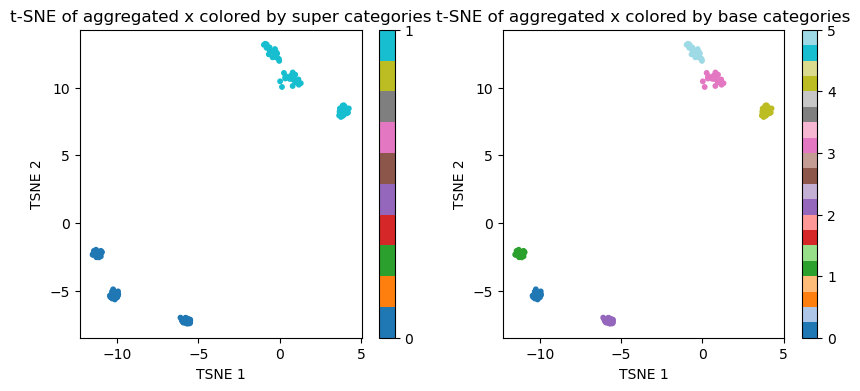

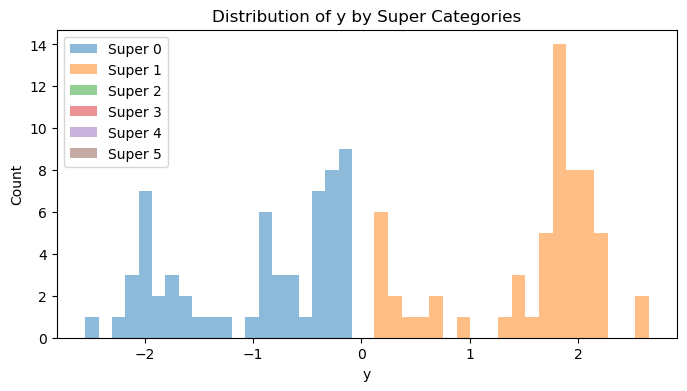

/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


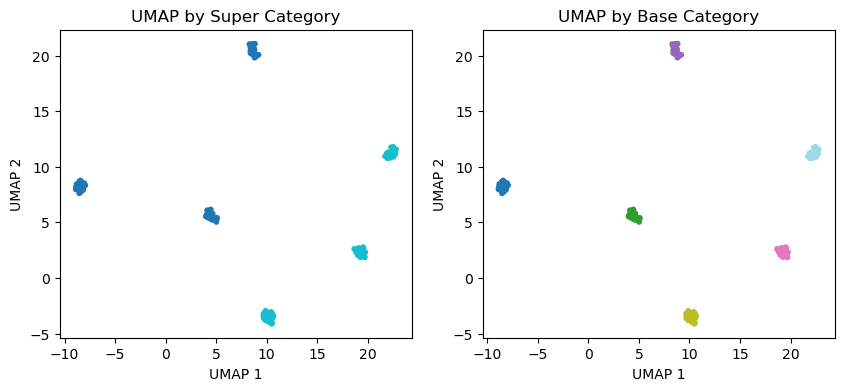

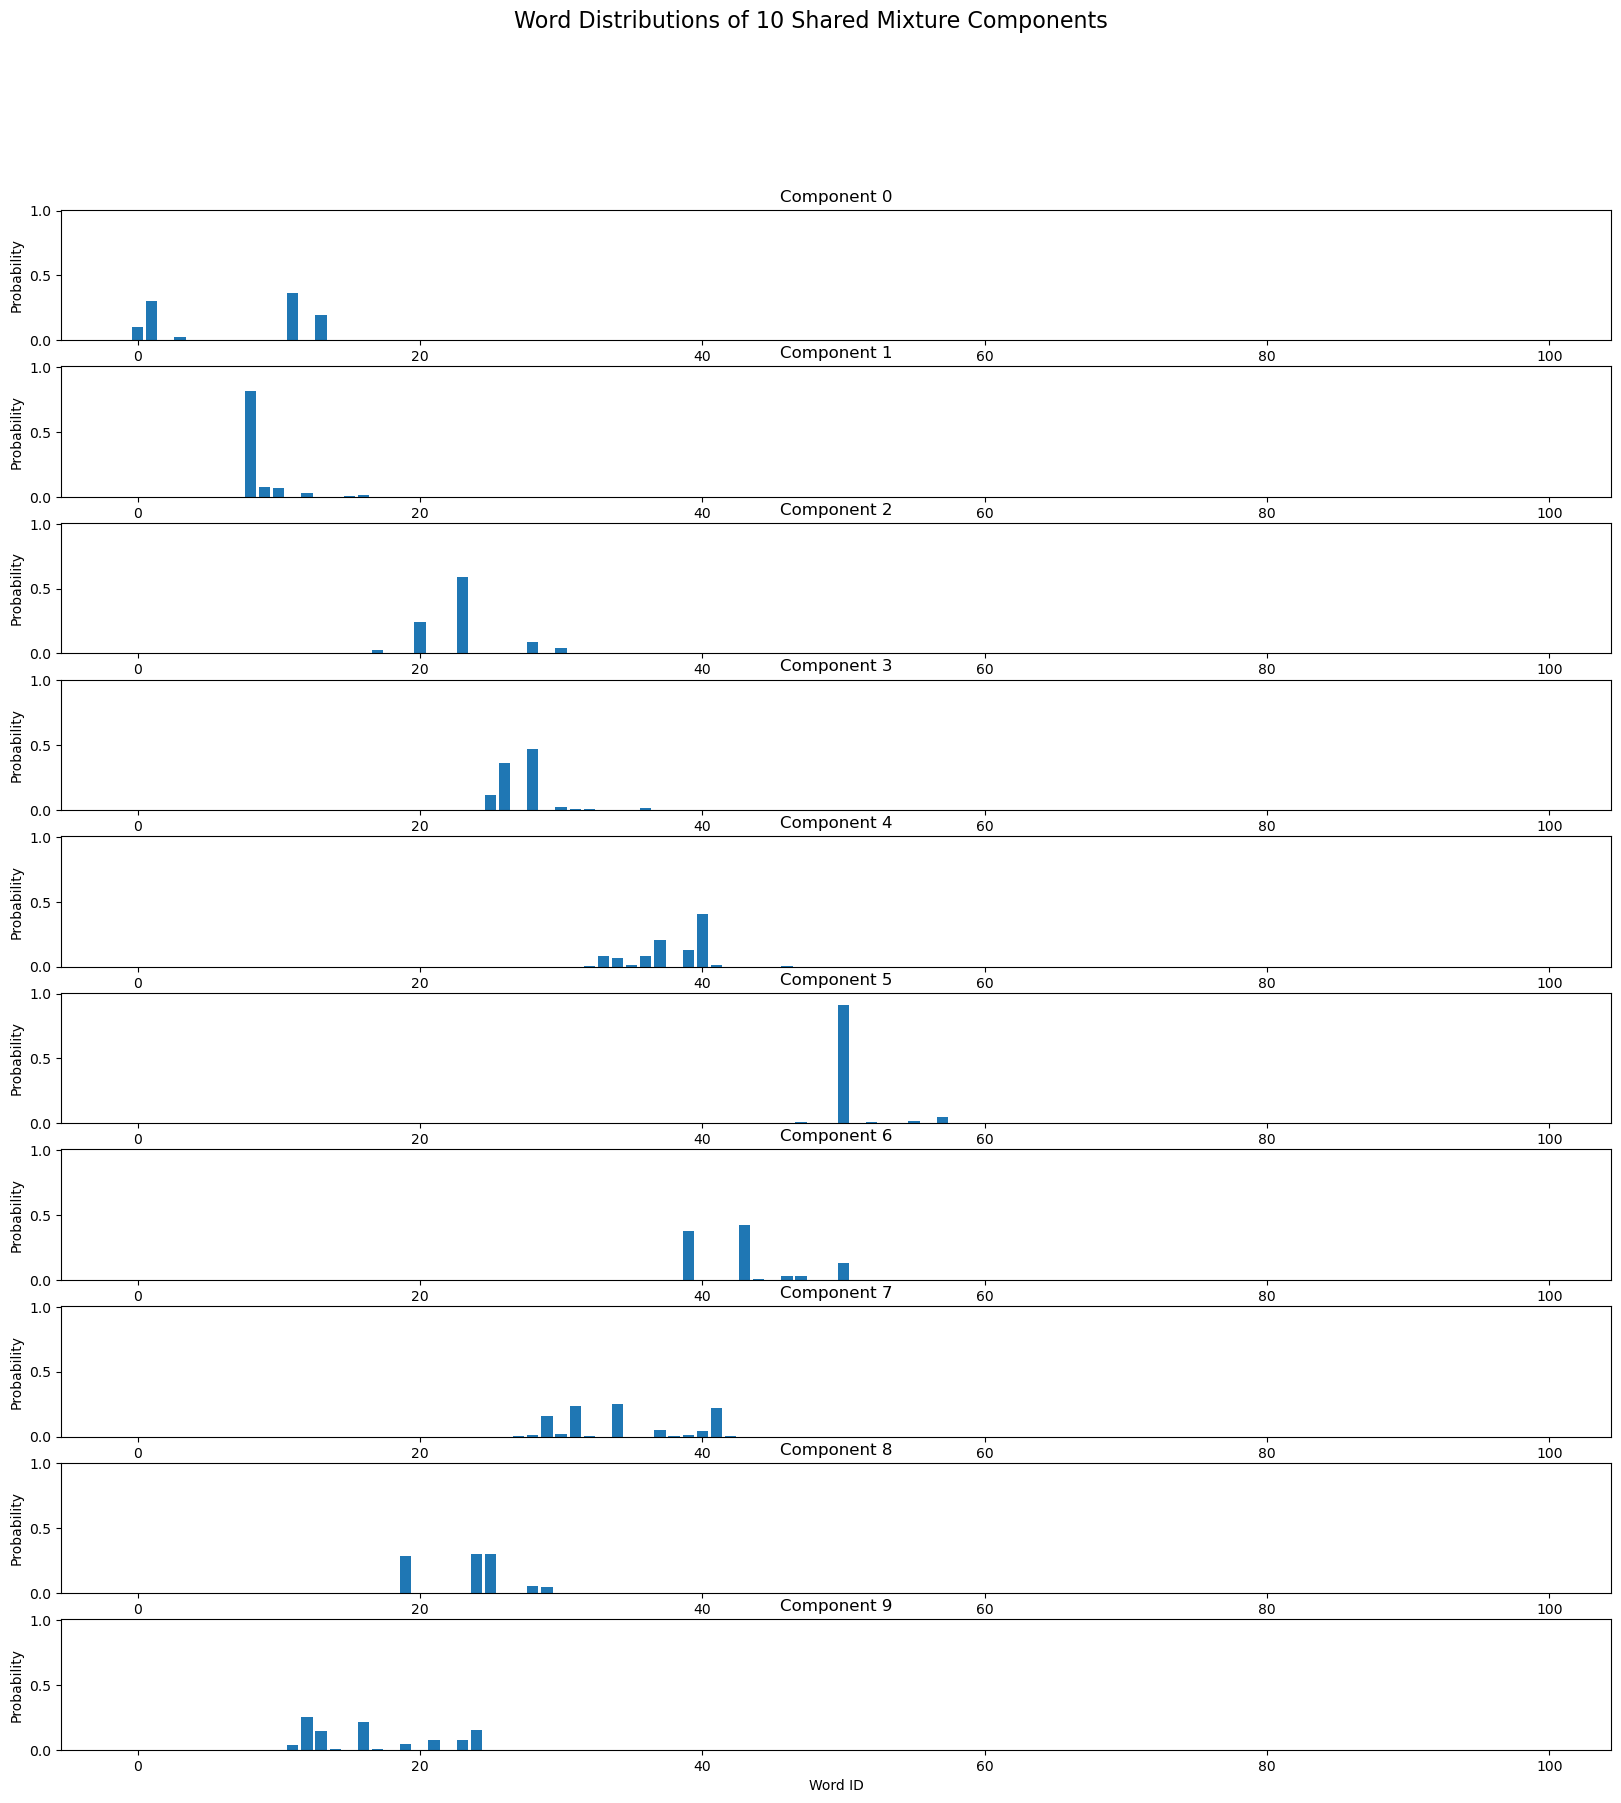

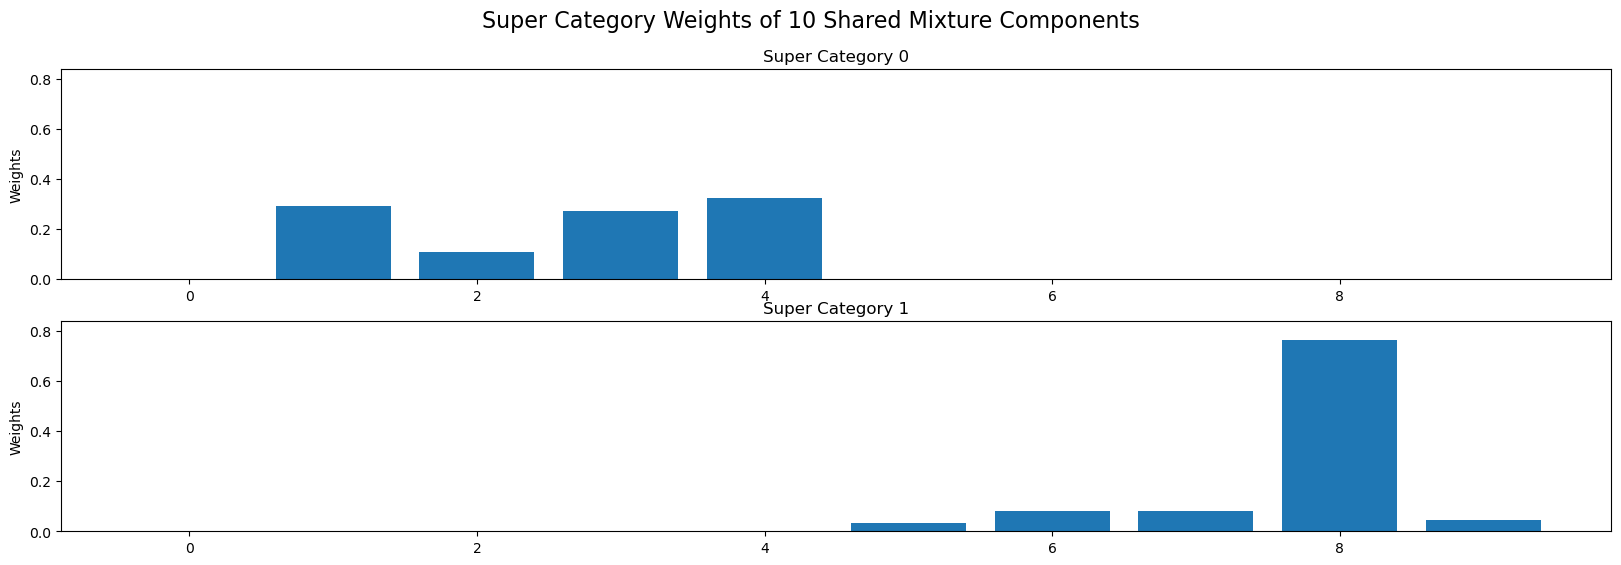

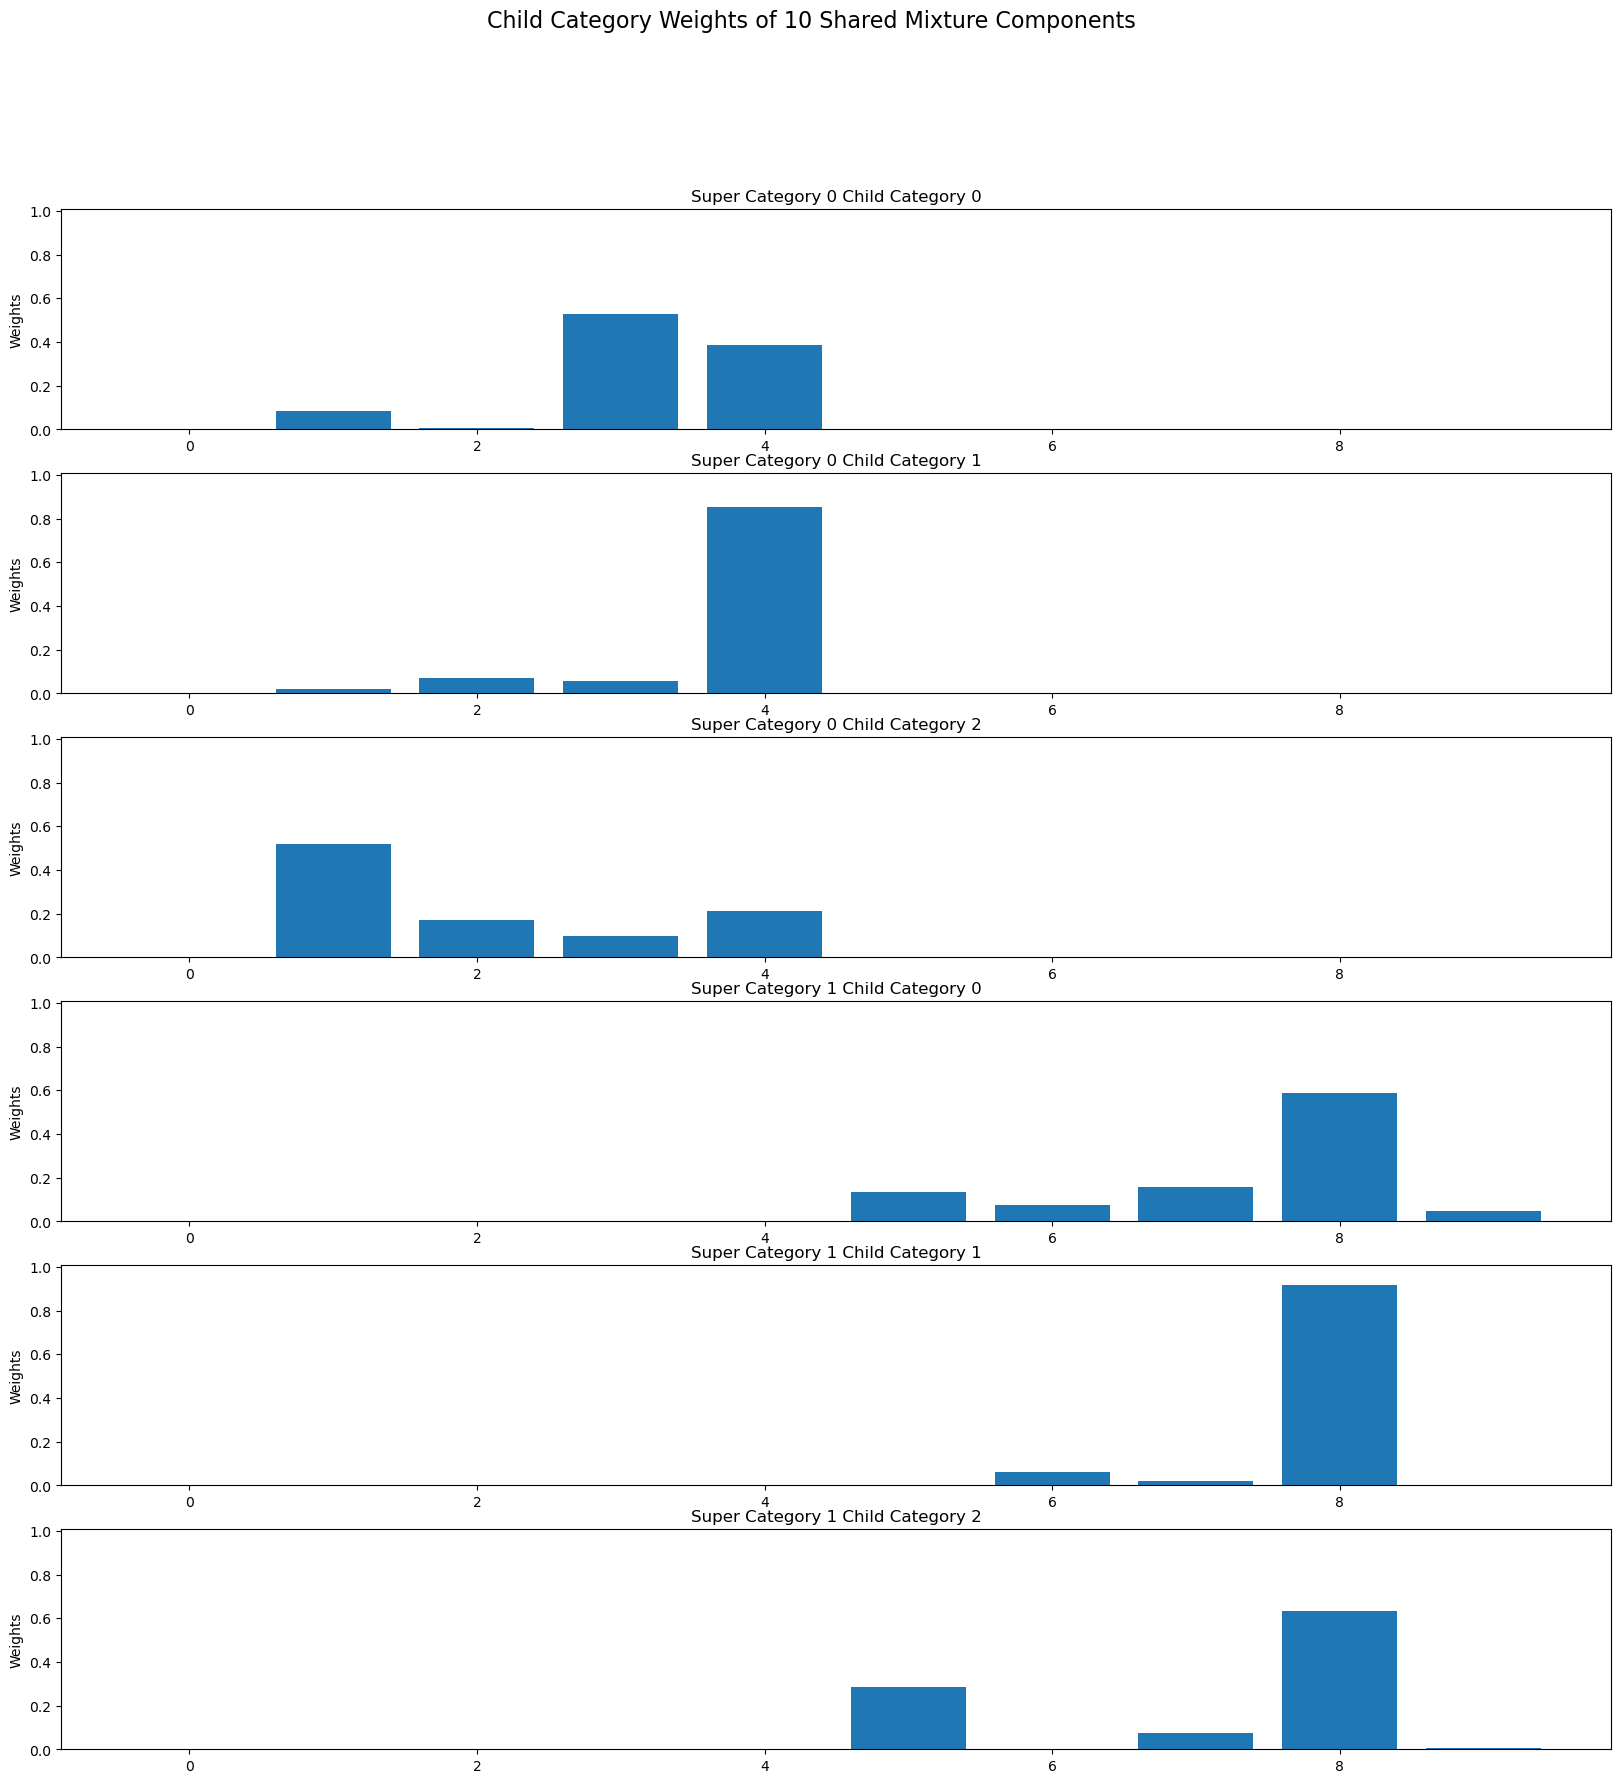

In [9]:
struct_upbd = {"G0": 10, "G1": 2, "G2": 3}
data = generate_hierarchical_mixture_data_jax(struct_upbd)
tsne_visualization(data, struct_upbd)
umap_visualization(data, struct_upbd)


In [36]:
import vis
import hdmm
import importlib
import hdmm_utils
importlib.reload(vis)
importlib.reload(hdmm)
importlib.reload(hdmm_utils)
from hdmm import HDMM
from vis import likelihood_visualization


known_cats = {}
# known_cats[0] = data["super_labels"]
known_cats[1] = data["base_labels"] % struct_upbd["G2"]  # make sure base labels are in [0, G2-1]
known_mixtures = {}
known_mixtures["generation"] = data["word_dists"]
known_struct = {0: data["super_mix_weights"], 1: jnp.transpose(data["child_mix_weights"], (1, 0, 2)) }
known_words = data["x_labels"]

model = HDMM(struct_upbd, vocab_size=100)
print("Model initialized.")

z_gen, z_reg, local_category_assignments, mc, doc_values, log_prob = model.infer(data["x"], data["y"], num_iters=10, known_struct=known_struct, key=random.PRNGKey(10))
print("Inference completed.")
likelihood_visualization(log_prob, np.zeros_like(log_prob), epoch=3)

Model initialized.


Gibbs Sampling (Iter 10) LogProb -41232.91: 100%|██████████| 10/10 [00:01<00:00,  5.13it/s]


Inference completed.


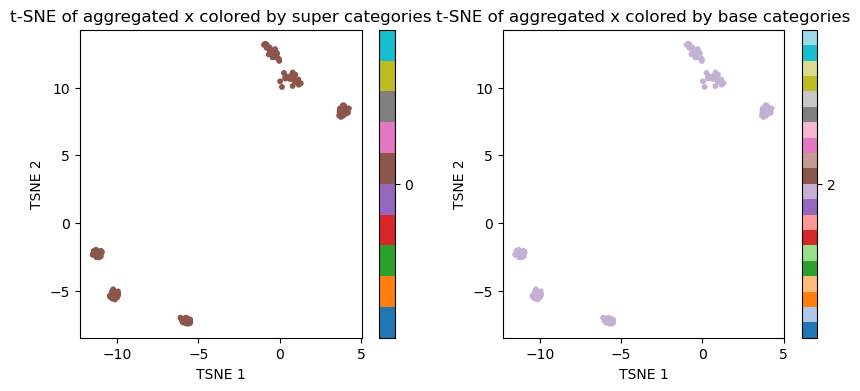

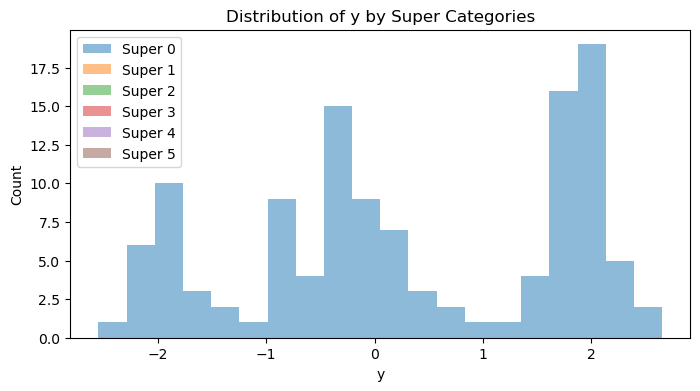

/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


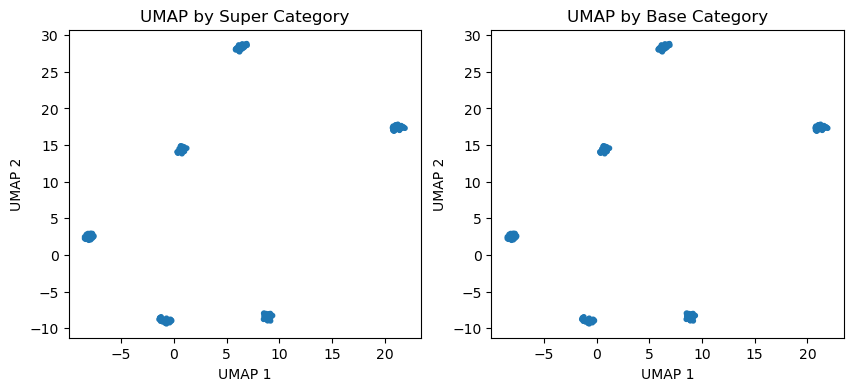

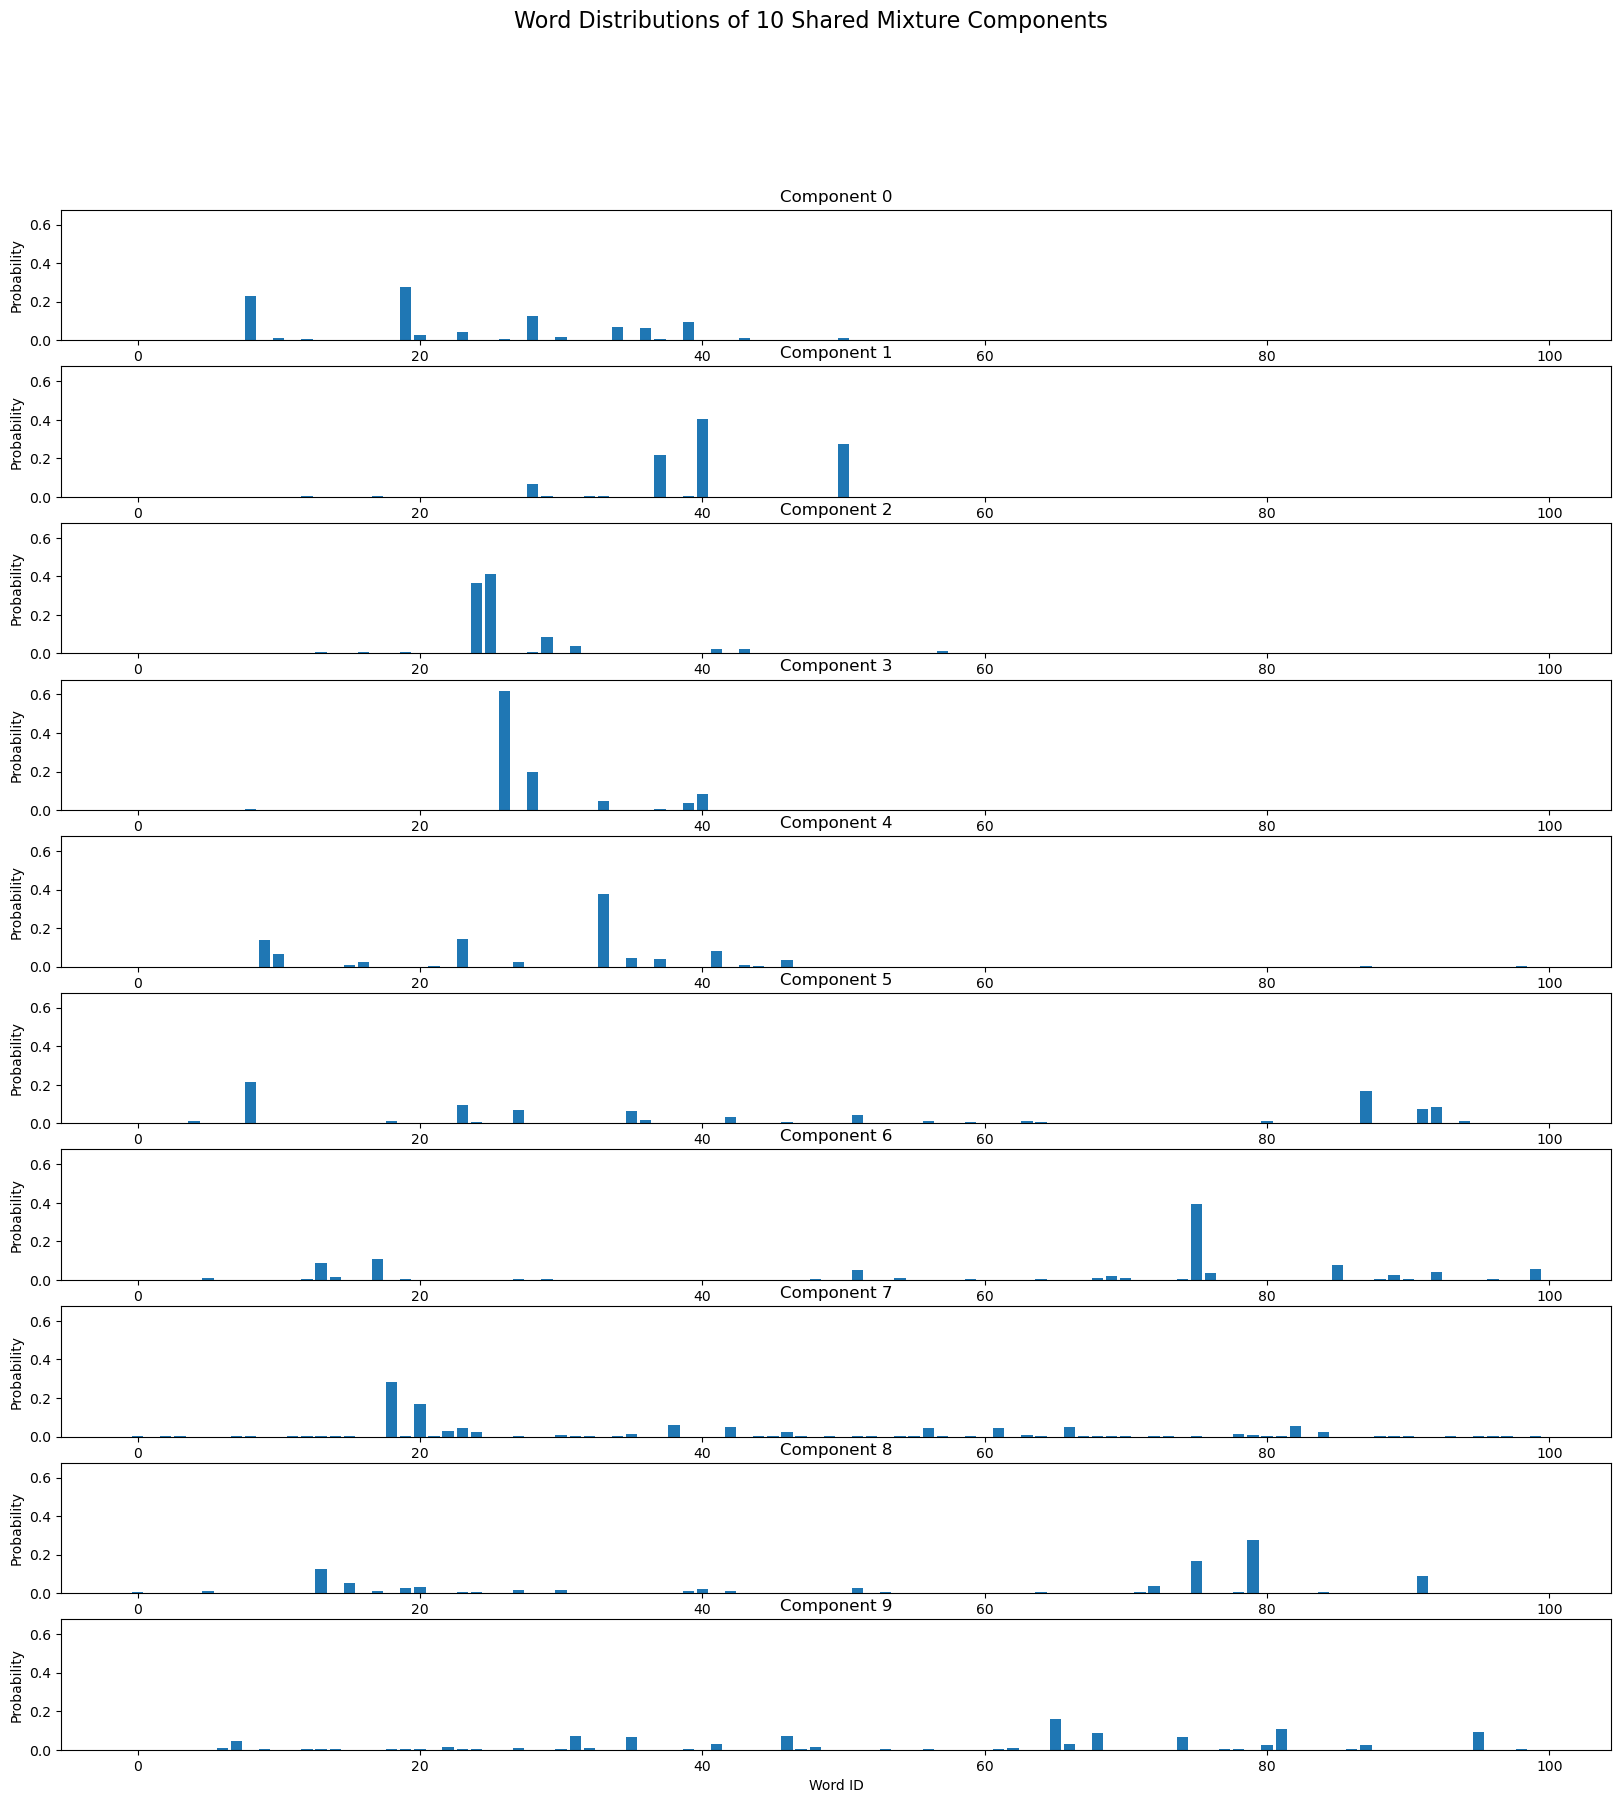

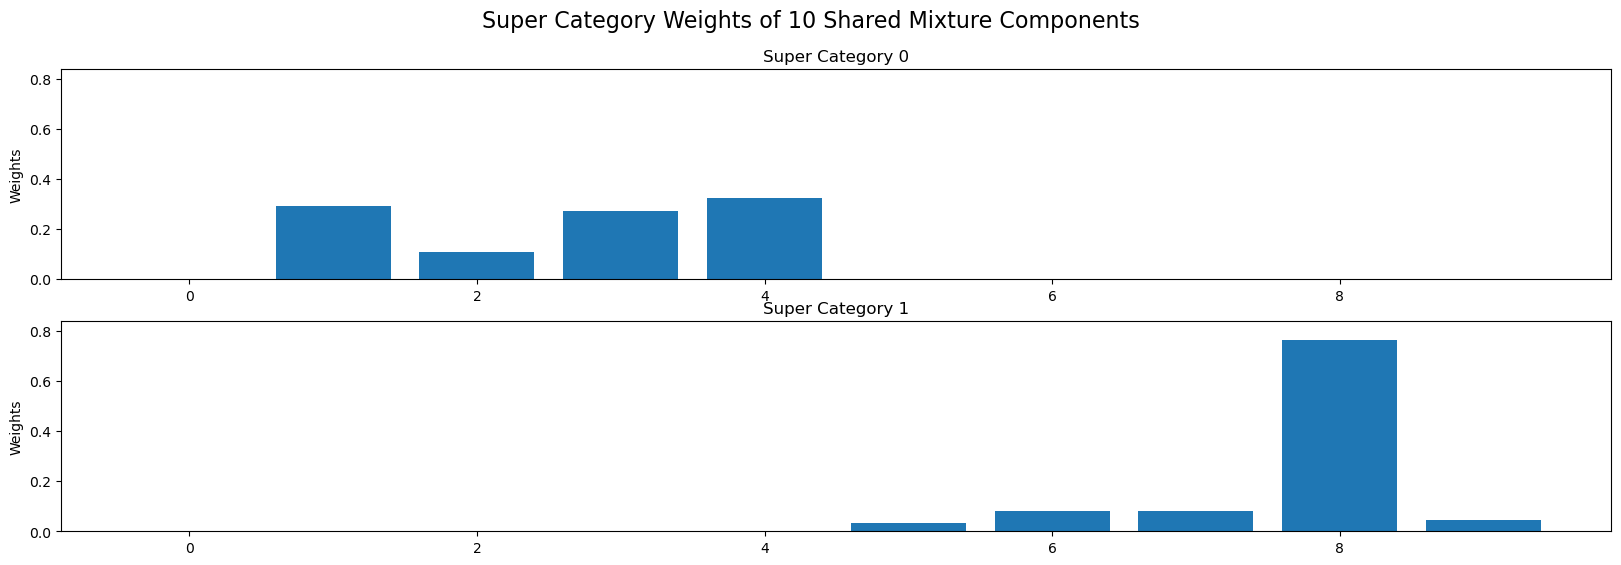

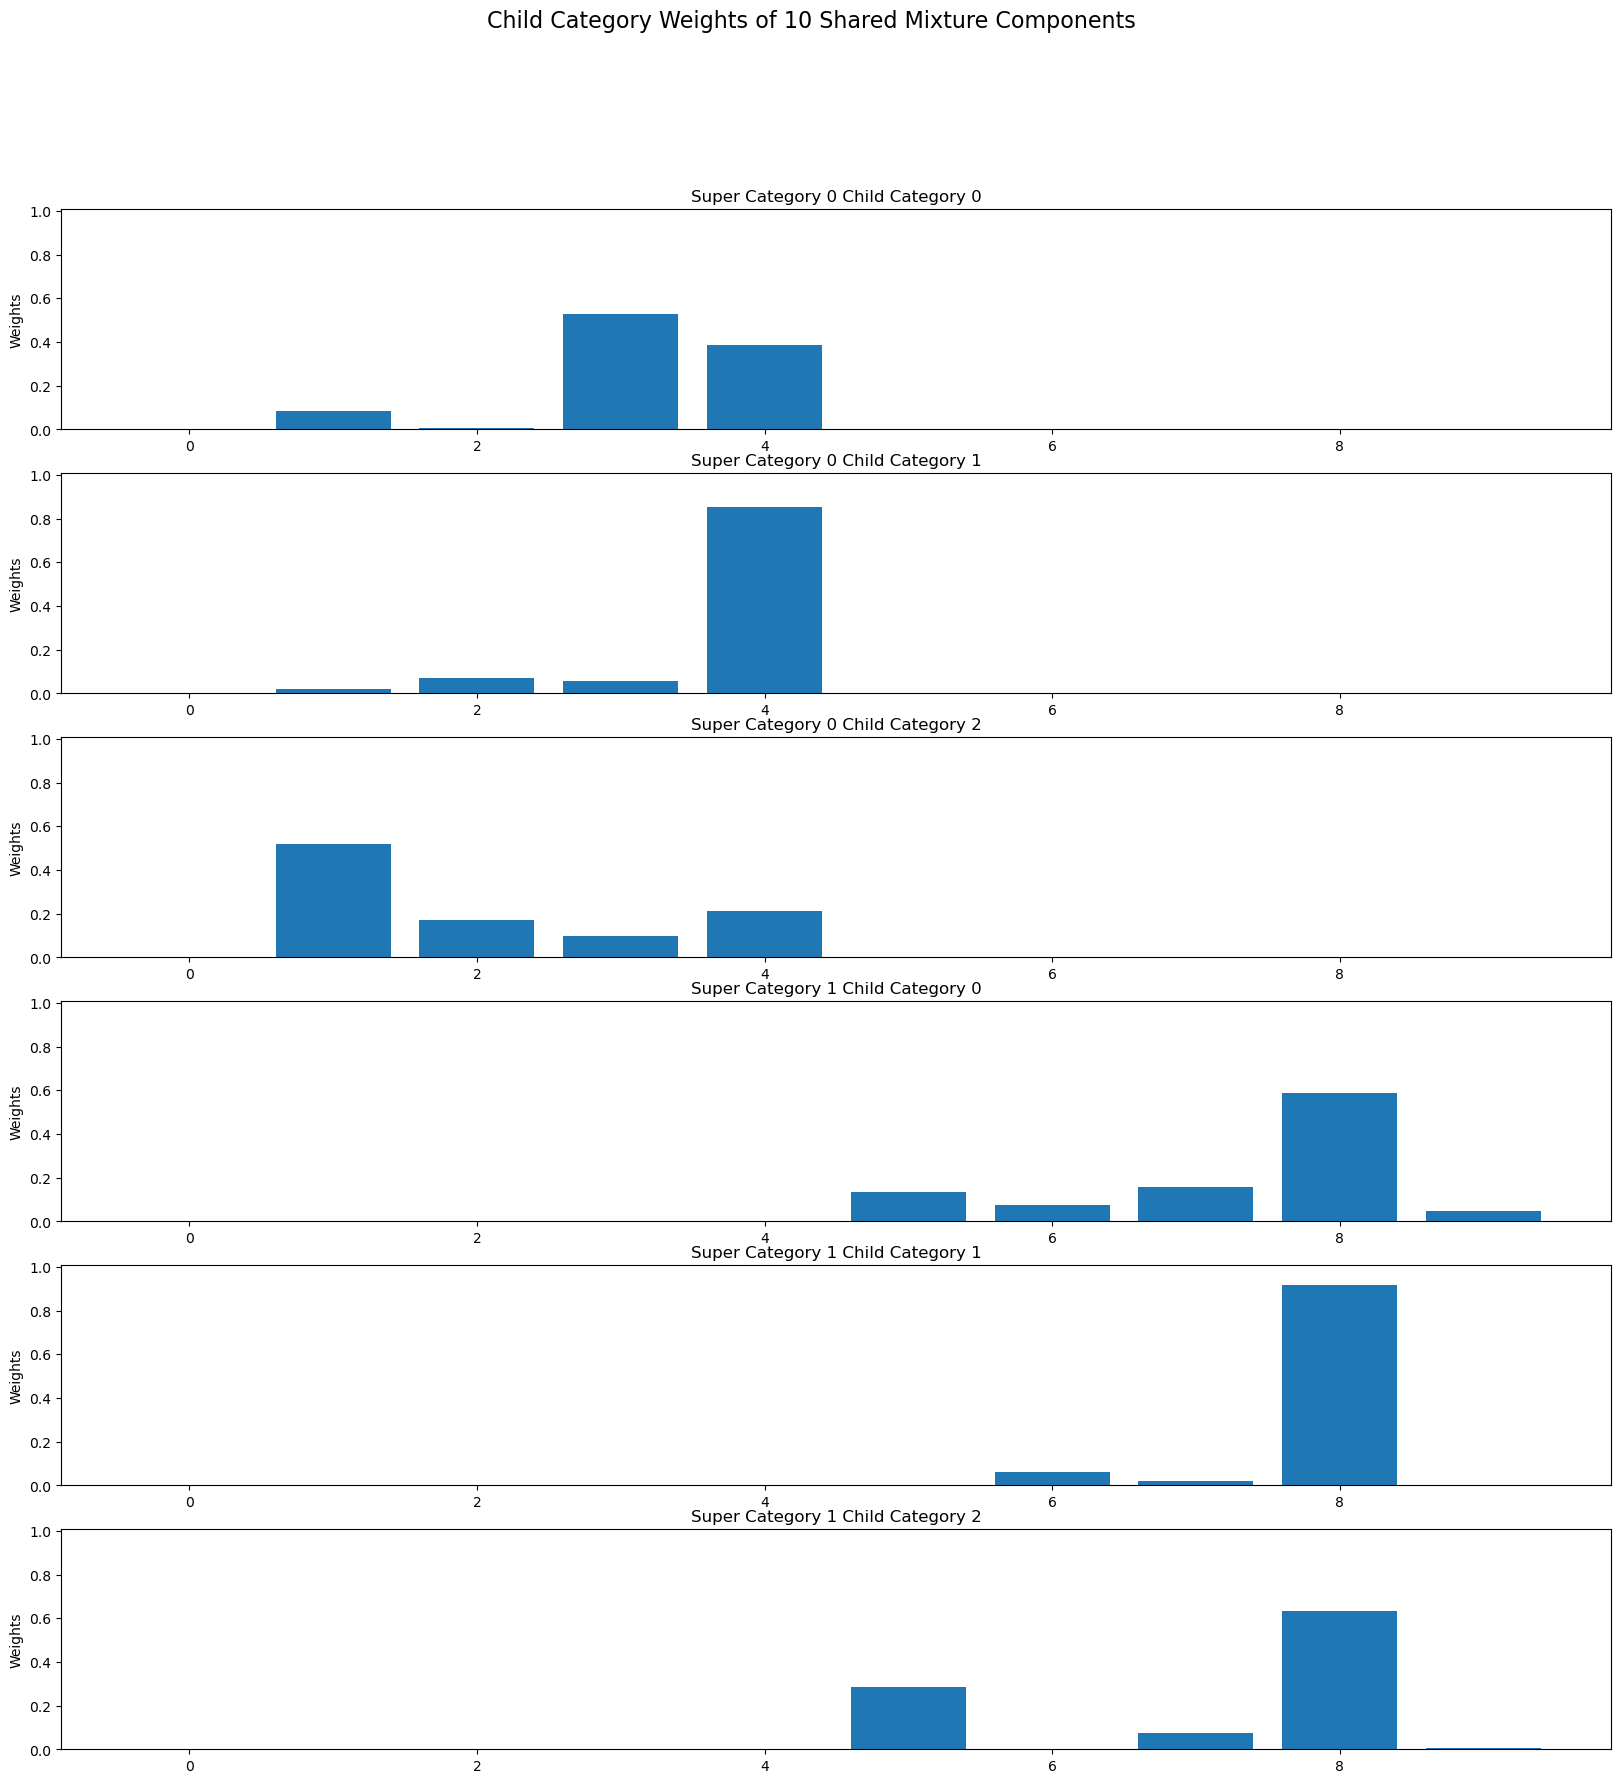

In [37]:
post_state = {
    "struct_params": model.struct_params,
    "struct_values": model.struct_values,
    "mixture_components": {
        "generation": model.mixture_components["generation"],
        "regression_mu": model.mixture_components["regression_mu"],
        "regression_sigma": model.mixture_components["regression_sigma"],
    },
    "local_category_assignments": local_category_assignments,
    "doc_values": None,
    "words": {
        "z_gen": z_gen,
        "z_reg": z_reg,
        "obs": data["x"],
        "reg": data["y"],
    },
}
markov_chain = mc
model_return = (post_state, markov_chain)
data_summary(model_return, data, struct_upbd)